# WAN Anomaly Detection Project Notebook

This notebook documents the end-to-end machine learning workflow for **enterprise WAN anomaly detection** using telemetry data.  
It includes:
- dataset loading and validation
- time-based train/test split
- feature engineering
- classical ML model comparison
- PyTorch MLP comparison
- SHAP-based interpretation

> Note: Run this notebook from the `notebooks/` folder inside your project, or adjust paths as needed.


In [14]:
import os
import sys
sys.path.append("../src")
from pathlib import Path

import numpy as np
import pandas as pd
df = pd.read_parquet("../data/processed/dataset.parquet")

print(df.shape)
df.head()

import matplotlib.pyplot as plt

# Add project source folder to Python path
sys.path.append('../src')

PROJECT_ROOT = Path('..')
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'dataset.parquet'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
MODELS_DIR = ARTIFACTS_DIR / 'models'
PLOTS_DIR = ARTIFACTS_DIR / 'plots'

print('Project root:', PROJECT_ROOT.resolve())
print('Dataset path:', DATA_PATH)


(80640, 89)
Project root: /Users/asanga/Purdue_MS/ECE57000/Practice_Work/tinyrepro_wan_anomaly
Dataset path: ../data/processed/dataset.parquet


## 1. Load Processed Dataset

This dataset contains telemetry features and anomaly labels created during preprocessing.


In [15]:
df = pd.read_parquet(DATA_PATH)
print(df.shape)
df.head()


(80640, 89)


,timestamp,site_id,link_id,link_type,latency_ms,jitter_ms,loss_pct,throughput_mbps,congestion_pct,flag_latency_ms,...,congestion_pct_mean_60m,congestion_pct_std_60m,congestion_pct_max_60m,congestion_pct_mean_360m,congestion_pct_std_360m,congestion_pct_max_360m,congestion_pct_mean_1440m,congestion_pct_std_1440m,congestion_pct_max_1440m,congestion_pct_delta1
0,2025-01-01 00:00:00+00:00,S000,S000-L0,mpls,29.761793,2.527322,0.504421,180.570638,44.895109,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 00:15:00+00:00,S000,S000-L0,mpls,26.661652,4.948645,0.133909,178.747050,44.429111,0,...,44.662110,0.329510,44.895109,NaN,NaN,NaN,NaN,NaN,NaN,-0.465997
2,2025-01-01 00:30:00+00:00,S000,S000-L0,mpls,31.398233,3.641948,0.222566,153.041885,46.909525,0,...,45.411248,1.318300,46.909525,NaN,NaN,NaN,NaN,NaN,NaN,2.480414
3,2025-01-01 00:45:00+00:00,S000,S000-L0,mpls,32.131773,2.981263,0.265174,167.057213,58.792523,0,...,48.756567,6.776668,58.792523,NaN,NaN,NaN,NaN,NaN,NaN,11.882997
4,2025-01-01 01:00:00+00:00,S000,S000-L0,mpls,25.157688,4.214675,0.394165,201.814690,62.565863,0,...,53.174256,8.859865,62.565863,NaN,NaN,NaN,NaN,NaN,NaN,3.773340


## 2. Inspect Class Distribution

This checks how imbalanced the anomaly detection problem is.


In [16]:
class_counts = df['anomaly'].value_counts().sort_index()
class_rates = df['anomaly'].value_counts(normalize=True).sort_index()

print('Class counts:')
print(class_counts)
print('\nClass rates:')
print(class_rates)


Class counts:
anomaly
0    78565
1     2075
Name: count, dtype: int64

Class rates:
anomaly
0    0.974268
1    0.025732
Name: proportion, dtype: float64


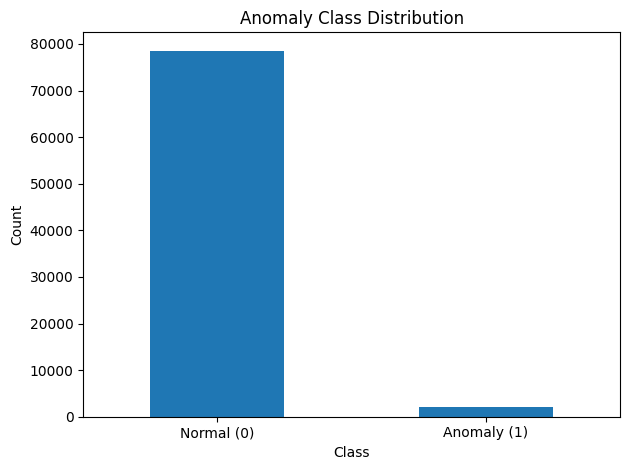

In [17]:
class_counts.plot(kind='bar')
plt.title('Anomaly Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Normal (0)', 'Anomaly (1)'], rotation=0)
plt.tight_layout()
plt.show()


## 3. Time-Based Train/Test Split

We use a time-aware split to avoid leakage from future timestamps.


In [18]:
from wan_anomaly.processing.split import time_split

train_idx, test_idx, cutoff = time_split(df, 'timestamp', train_frac=0.8)
print('Cutoff timestamp:', cutoff)
print('Train size:', int(train_idx.sum()))
print('Test size :', int(test_idx.sum()))
print('Train anomaly rate:', df.loc[train_idx, 'anomaly'].mean())
print('Test anomaly rate :', df.loc[test_idx, 'anomaly'].mean())


Cutoff timestamp: 2025-01-12 04:45:00+00:00
Train size: 64560
Test size : 16080
Train anomaly rate: 0.02577447335811648
Test anomaly rate : 0.025559701492537314


## 4. Build ML Feature Matrix

This step converts the processed dataframe into a fully numeric feature matrix for model training.


In [19]:
from wan_anomaly.processing.features import make_ml_table

drop_cols = ['site_id', 'link_id', 'timestamp']
X, y = make_ml_table(df, drop_cols=drop_cols, label_col='anomaly')

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
X_train.head()


X_train shape: (64560, 86)
X_test shape : (16080, 86)


,latency_ms,jitter_ms,loss_pct,throughput_mbps,congestion_pct,flag_latency_ms,flag_jitter_ms,flag_loss_pct,flag_throughput_mbps,flag_congestion_pct,...,congestion_pct_max_60m,congestion_pct_mean_360m,congestion_pct_std_360m,congestion_pct_max_360m,congestion_pct_mean_1440m,congestion_pct_std_1440m,congestion_pct_max_1440m,congestion_pct_delta1,link_type_lte5g,link_type_mpls
0,29.761793,2.527322,0.504421,180.570638,44.895109,0,0,0,0,0,...,54.943259,46.961527,12.342174,74.722558,45.455098,22.901351,89.356867,0.036998,False,True
1,26.661652,4.948645,0.133909,178.747050,44.429111,0,0,0,0,0,...,44.895109,46.961527,12.342174,74.722558,45.455098,22.901351,89.356867,-0.465997,False,True
2,31.398233,3.641948,0.222566,153.041885,46.909525,0,0,0,0,0,...,46.909525,46.961527,12.342174,74.722558,45.455098,22.901351,89.356867,2.480414,False,True
3,32.131773,2.981263,0.265174,167.057213,58.792523,0,0,0,0,0,...,58.792523,46.961527,12.342174,74.722558,45.455098,22.901351,89.356867,11.882997,False,True
4,25.157688,4.214675,0.394165,201.814690,62.565863,0,0,0,0,0,...,62.565863,46.961527,12.342174,74.722558,45.455098,22.901351,89.356867,3.773340,False,True


## 5. Train Classical ML Baselines

This step trains Logistic Regression, Random Forest, and SVM baselines.


In [42]:
from wan_anomaly.models.train import train_all

metrics_df, rates_df = train_all(
    X_train,
    y_train,
    X_test,
    y_test,
    out_dir=str(MODELS_DIR),
    random_state=42,
)
metrics_df


,name,accuracy,precision,recall,f1,roc_auc,pr_auc,pred_anomaly_rate
0,logreg,1.0,1.0,1.0,1.0,1.0,1.0,0.02556
1,rf,1.0,1.0,1.0,1.0,1.0,1.0,0.02556
2,svm_rbf,1.0,1.0,1.0,1.0,1.0,1.0,0.02556


## 6. Train PyTorch MLP

This extends the project with a neural network baseline for Checkpoint 2.


In [21]:
from wan_anomaly.models.mlp_torch import train_mlp_classifier

mlp_model, mlp_metrics, mlp_probs, mlp_scaler = train_mlp_classifier(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=25,
    batch_size=256,
    lr=1e-3,
    random_state=42,
)

mlp_metrics


{'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'roc_auc': 1.0,
 'pr_auc': 1.0,
 'pred_anomaly_rate': 0.025559701492537314}

## 7. Compare All Models

Append the PyTorch MLP results to the classical baseline table.


In [22]:
mlp_row = {
    'name': 'mlp_torch',
    'accuracy': mlp_metrics['accuracy'],
    'precision': mlp_metrics['precision'],
    'recall': mlp_metrics['recall'],
    'f1': mlp_metrics['f1'],
    'roc_auc': mlp_metrics['roc_auc'],
    'pr_auc': mlp_metrics['pr_auc'],
    'pred_anomaly_rate': mlp_metrics['pred_anomaly_rate'],
}

metrics_all = pd.concat([metrics_df, pd.DataFrame([mlp_row])], ignore_index=True)
metrics_all = metrics_all.sort_values('pr_auc', ascending=False)
metrics_all


,name,accuracy,precision,recall,f1,roc_auc,pr_auc,pred_anomaly_rate
0,logreg,1.0,1.0,1.0,1.0,1.0,1.0,0.02556
1,rf,1.0,1.0,1.0,1.0,1.0,1.0,0.02556
2,svm_rbf,1.0,1.0,1.0,1.0,1.0,1.0,0.02556
3,mlp_torch,1.0,1.0,1.0,1.0,1.0,1.0,0.02556


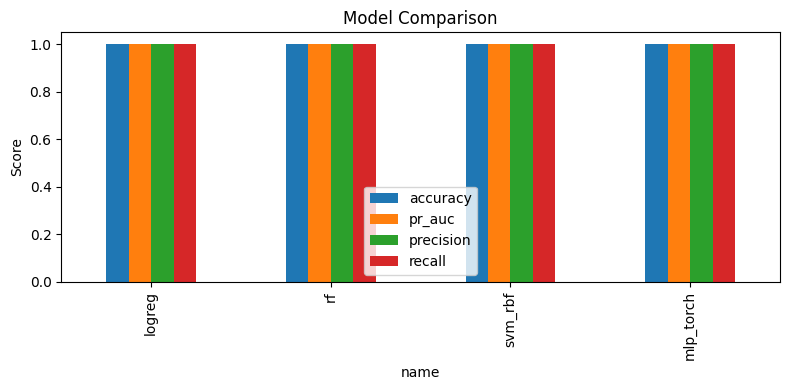

In [23]:
metrics_all[['name', 'accuracy', 'pr_auc', 'precision', 'recall']].plot(
    x='name', kind='bar', figsize=(8, 4)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.show()


## 8. SHAP-Based Interpretation for Random Forest

This section explains the Random Forest model using SHAP.  
If your SHAP environment is unstable, you can skip this section and rely on saved plots.


In [27]:
import shap
from joblib import load
import warnings
warnings.filterwarnings("ignore")

rf_model = load(MODELS_DIR / 'rf.joblib')
X_test_float = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).astype('float64')

explainer = shap.TreeExplainer(rf_model, model_output='raw', feature_perturbation='tree_path_dependent')
shap_values = explainer.shap_values(X_test_float)
shap_values = shap_values[1] if isinstance(shap_values, list) else shap_values

print('SHAP values shape:', np.asarray(shap_values).shape)


SHAP values shape: (16080, 86, 2)


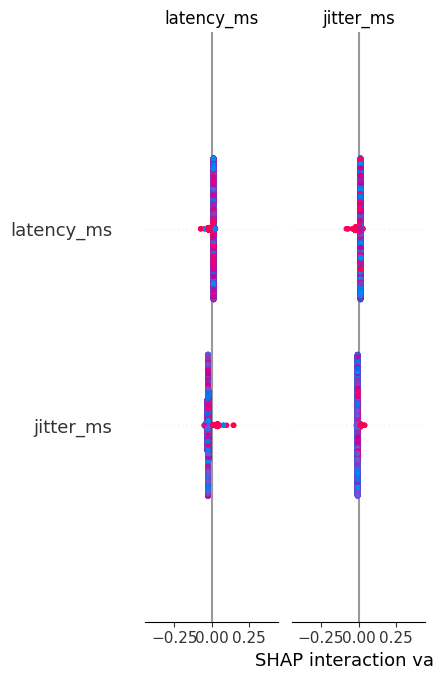

In [28]:
shap.summary_plot(shap_values, X_test_float, show=True)


In [33]:
import numpy as np
import pandas as pd

# Inspect the shape first
print("shap_values type:", type(shap_values))
print("shap_values shape:", np.array(shap_values).shape)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_vals = shap_values[1]   # anomaly class
else:
    shap_vals = np.array(shap_values)

    # If shape is (samples, features, classes), keep class 1
    if shap_vals.ndim == 3 and shap_vals.shape[-1] == 2:
        shap_vals = shap_vals[:, :, 1]

    # If shape is (features, classes), keep class 1
    elif shap_vals.ndim == 2 and shap_vals.shape[1] == 2:
        shap_vals = shap_vals[:, 1]

print("Final shap_vals shape:", shap_vals.shape)

importance = np.abs(shap_vals).mean(axis=0)

importance_series = pd.Series(
    importance,
    index=X_test_float.columns
).sort_values(ascending=False)

importance_series.head(10)

shap_values type: <class 'numpy.ndarray'>
shap_values shape: (16080, 86, 2)
Final shap_vals shape: (16080, 86)


flag_latency_ms       0.074290
flag_loss_pct         0.073949
loss_pct_max_15m      0.050479
flag_jitter_ms        0.048116
loss_pct_mean_15m     0.035002
loss_pct              0.032814
loss_pct_max_60m      0.030426
latency_ms            0.012442
loss_pct_mean_60m     0.012248
latency_ms_max_15m    0.012094
dtype: float64

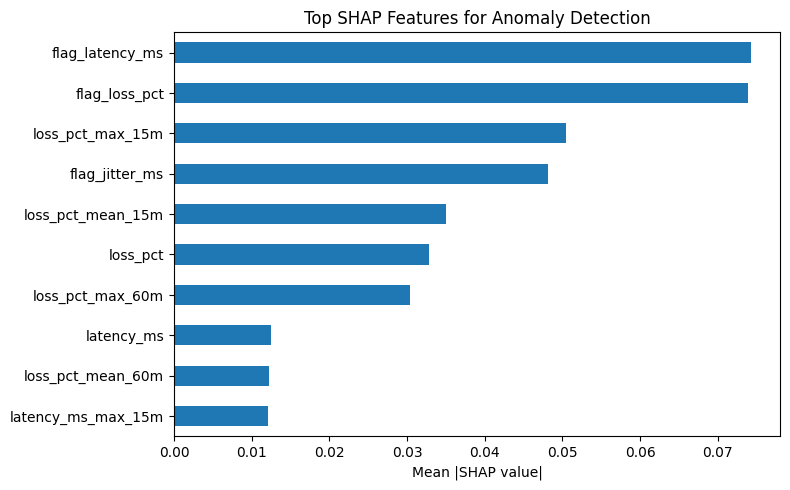

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = np.array(shap_values)
    if shap_vals.ndim == 3 and shap_vals.shape[-1] == 2:
        shap_vals = shap_vals[:, :, 1]

importance = np.abs(shap_vals).mean(axis=0)

importance_series = pd.Series(
    importance,
    index=X_test_float.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance_series.head(10).sort_values().plot(kind="barh")
plt.title("Top SHAP Features for Anomaly Detection")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

## 9. Save Combined Results

This saves a unified metrics table that includes the PyTorch MLP.


In [41]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
metrics_all.to_csv(ARTIFACTS_DIR / 'metrics_table_with_mlp.csv', index=False)
print('Saved:', ARTIFACTS_DIR / 'metrics_table_with_mlp.csv')


Saved: ../artifacts/metrics_table_with_mlp.csv


## 10. Discussion Notes

- If all models perform nearly perfectly, the current feature space may make anomalies highly separable.
- If the PyTorch MLP does not outperform Random Forest, that is still a valid result for tabular telemetry data.
- Future work can explore threshold tuning, robustness tests, and cross-device validation.
